# 22 — FNSPID sentiment-surprise strategy translation

**Question.** Notebook 4 found small evaluation prediction-loss gains from
firm-demeaned and fully demeaned sentiment surprise. Can either result support
an economically viable cross-sectional portfolio?

## Frozen development-only feasibility design

- **Spine:** FNSPID only, using Notebook 4's existing surprise panel and the
  dense adjusted-open market-adjusted return panel.
- **Signals:** `surprise_firm` and `surprise_full`; higher surprise is oriented
  long because both development coefficients were positive.
- **Family:** 2 signals × holding horizons 1/5/10 × centred-rank breadth bands
  0.5/0.8 = 12 predeclared arms.
- **Portfolio:** separately normalised +0.5/-0.5 legs, at least 10 names, dense
  returns through no-news sessions, overlapping tranches for multi-day holds.
- **Primary cost:** 10 bps per side, including final liquidation. The fixed
  diagnostic grid is 0/0.5/1/2/5/10 bps on the best gross arm.
- **Inference:** 10-session circular block bootstrap, 999 replications, seed
  20260731, inherited from the existing strategy helper.
- **Gate:** evaluation is not opened unless a development arm has at least 250
  sessions and 10 mean positions, positive net Sharpe, break-even cost at
  least 10 bps/side, and a positive net-mean bootstrap lower bound.

The family is intentionally small. This notebook tests translation, not a new
broad hyperparameter search.

In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.panel import (  # noqa: E402
    DEFAULT_PRICE_ZIP,
    load_adjusted_open_prices,
)
from final_experiments.lib.plots import (  # noqa: E402
    CATEGORICAL,
    INK,
    STATUS,
    apply_house_style,
)
from final_experiments.lib.risk_overlay import reprice_daily  # noqa: E402
from final_experiments.lib.strategy import (  # noqa: E402
    StrategyConfig,
    assess_deployment_viability,
    backtest_on_grid,
    build_daily_ar_panel,
    build_grid,
    summarize_backtest,
    sweep_development,
)

apply_house_style()
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

SURPRISE_PATH = (
    REPO_ROOT / "final_experiments" / "outputs" / "04_surprise" / "firm_day_surprise.parquet"
)
OUTPUT_DIR = REPO_ROOT / "final_experiments" / "outputs" / "22_fnspid_surprise_strategy_translation"
SIGNALS = ("surprise_firm", "surprise_full")
HORIZONS = (1, 5, 10)
BREADTHS = (0.5, 0.8)
COST_BPS = 10.0
COST_GRID = (0.0, 0.5, 1.0, 2.0, 5.0, 10.0)
MIN_NAMES = 10
SEED = 20260731
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"repo:   {REPO_ROOT}")
print(f"output: {OUTPUT_DIR}")
print(f"seed:   {SEED}")

repo:   /Users/peterprendergast/Documents/Sentiment_Dissertation
output: /Users/peterprendergast/Documents/Sentiment_Dissertation/final_experiments/outputs/22_fnspid_surprise_strategy_translation
seed:   20260731


## Load the already-fitted surprise panel and dense prices

No scorer is rerun. Licensed headline text is never loaded.

In [2]:
if not SURPRISE_PATH.exists():
    raise FileNotFoundError(f"Run Notebook 4 first; missing {SURPRISE_PATH}")
if not DEFAULT_PRICE_ZIP.exists():
    raise FileNotFoundError(DEFAULT_PRICE_ZIP)

surprise = pd.read_parquet(SURPRISE_PATH)
surprise["session_date"] = pd.to_datetime(surprise["session_date"]).dt.normalize()
symbols = set(surprise["symbol"].astype(str).str.upper())
prices, missing_symbols = load_adjusted_open_prices(DEFAULT_PRICE_ZIP, symbols)
daily_ar = build_daily_ar_panel(prices)

input_audit = pd.DataFrame(
    [
        {
            "panel_rows": len(surprise),
            "development_rows": int(surprise["split"].eq("development").sum()),
            "evaluation_rows_not_used": int(surprise["split"].eq("evaluation").sum()),
            "symbols": surprise["symbol"].nunique(),
            "development_sessions": surprise.loc[
                surprise["split"].eq("development"), "session_date"
            ].nunique(),
            "dense_return_rows": len(daily_ar),
            "missing_price_symbols": len(missing_symbols),
        }
    ]
)
if missing_symbols:
    raise RuntimeError(f"missing price symbols: {missing_symbols[:10]}")
display(input_audit)

,panel_rows,development_rows,evaluation_rows_not_used,symbols,development_sessions,dense_return_rows,missing_price_symbols
0,715546,512153,203393,570,2264,1810810,0


## Mechanism audit: cross-sectional demeaning does not change ranks

`surprise_full = surprise_firm - cs_mean`, and `cs_mean` is one constant per
session. Therefore the two signals can differ in regression scale while being
the same cross-sectional trading signal.

In [3]:
rank_frame = surprise.loc[
    surprise["split"].eq("development"),
    ["session_date", "symbol", "surprise_firm", "surprise_full"],
].dropna()
rank_frame["rank_firm"] = rank_frame.groupby("session_date")["surprise_firm"].rank(
    method="average", pct=True
)
rank_frame["rank_full"] = rank_frame.groupby("session_date")["surprise_full"].rank(
    method="average", pct=True
)
rank_frame["rank_difference"] = rank_frame["rank_full"] - rank_frame["rank_firm"]
rank_audit = pd.DataFrame(
    [
        {
            "rows": len(rank_frame),
            "sessions": rank_frame["session_date"].nunique(),
            "pooled_signal_spearman": rank_frame[["surprise_firm", "surprise_full"]]
            .corr(method="spearman")
            .iloc[0, 1],
            "maximum_absolute_rank_difference": rank_frame["rank_difference"].abs().max(),
            "rows_with_different_rank": int(rank_frame["rank_difference"].abs().gt(1e-12).sum()),
        }
    ]
)
assert rank_audit.loc[0, "rows_with_different_rank"] == 0
display(rank_audit)

,rows,sessions,pooled_signal_spearman,maximum_absolute_rank_difference,rows_with_different_rank
0,509303,2259,0.986010,0.000000,0


## Run the complete 12-arm development family

In [4]:
sweep = sweep_development(
    surprise,
    daily_ar,
    signals=SIGNALS,
    horizons=HORIZONS,
    breadths=BREADTHS,
    orients={signal: 1.0 for signal in SIGNALS},
    cost_bps_per_side=COST_BPS,
    min_names=MIN_NAMES,
)
sweep = sweep.sort_values(
    ["sharpe_net", "annualized_turnover"], ascending=[False, True], kind="mergesort"
).reset_index(drop=True)
display(
    sweep[
        [
            "signal",
            "horizon",
            "breadth",
            "n_sessions",
            "mean_positions",
            "sharpe_gross",
            "sharpe_net",
            "breakeven_bps_per_side",
            "bootstrap_net_ci_low",
            "annualized_turnover",
        ]
    ]
)

,signal,horizon,breadth,n_sessions,mean_positions,sharpe_gross,sharpe_net,breakeven_bps_per_side,bootstrap_net_ci_low,annualized_turnover
0,surprise_firm,10,0.800000,2254,289.543478,-0.084642,-2.710917,-0.322234,-0.000243,23.903101
1,surprise_full,10,0.800000,2254,289.543478,-0.084642,-2.710917,-0.322234,-0.000243,23.903101
2,surprise_firm,5,0.800000,2254,181.222715,0.329851,-3.502033,0.860916,-0.000407,47.529437
3,surprise_full,5,0.800000,2254,181.222715,0.329851,-3.502033,0.860916,-0.000407,47.529437
4,surprise_firm,10,0.500000,2257,432.657510,-0.381149,-4.131376,-1.016172,-0.000225,22.294659
5,surprise_full,10,0.500000,2257,432.657510,-0.381149,-4.131376,-1.016172,-0.000225,22.294659
6,surprise_firm,5,0.500000,2257,328.866637,0.178964,-5.126351,0.337438,-0.000381,44.118281
7,surprise_full,5,0.500000,2257,328.866637,0.178964,-5.126351,0.337438,-0.000381,44.118281
8,surprise_firm,1,0.800000,2254,45.687666,0.238673,-8.757611,0.265342,-0.001943,234.749825
9,surprise_full,1,0.800000,2254,45.687666,0.238673,-8.757611,0.265342,-0.001943,234.749825


In [5]:
paired_signal_check = sweep.pivot_table(
    index=["horizon", "breadth"],
    columns="signal",
    values=[
        "mean_gross",
        "sharpe_gross",
        "sharpe_net",
        "annualized_turnover",
        "breakeven_bps_per_side",
    ],
)
max_signal_result_difference = float(
    np.nanmax(
        np.abs(
            paired_signal_check.xs("surprise_firm", axis=1, level="signal").to_numpy()
            - paired_signal_check.xs("surprise_full", axis=1, level="signal").to_numpy()
        )
    )
)
assert max_signal_result_difference < 1e-12
print(f"Maximum paired strategy-result difference: {max_signal_result_difference:.3e}")

Maximum paired strategy-result difference: 0.000e+00


## Apply the existing cash gate before any evaluation run

In [6]:
deployment = assess_deployment_viability(
    sweep,
    cost_bps_per_side=COST_BPS,
    min_sessions=250,
    min_positions=MIN_NAMES,
    require_positive_net_ci=True,
)
gate_table = pd.DataFrame(
    [
        {
            "action": deployment["action"],
            "n_cells_considered": deployment["n_cells_considered"],
            "n_cells_eligible": deployment["n_cells_eligible"],
            "n_cells_clearing_cost": deployment["n_cells_clearing_cost"],
            "n_cells_deployable": deployment["n_cells_deployable"],
            "evaluation_opened_by_notebook22": False,
            "reason": deployment["reason"],
        }
    ]
)
if deployment["action"] != "cash":
    raise RuntimeError("Unexpected deployable arm; freeze its spec before any evaluation run")
display(gate_table)

,action,n_cells_considered,n_cells_eligible,n_cells_clearing_cost,n_cells_deployable,evaluation_opened_by_notebook22,reason
0,cash,12,12,0,0,False,no development cell clears the cost and uncert...


## Fixed cost curve for the strongest gross development construction

Selecting a development diagnostic is allowed; it does not change the cash
decision. Because the two signals are rank-identical, ties break to
`surprise_firm`, then lower turnover.

In [7]:
best_gross_row = (
    sweep.sort_values(
        ["sharpe_gross", "annualized_turnover", "signal"],
        ascending=[False, True, True],
        kind="mergesort",
    )
    .iloc[0]
)
best_config = StrategyConfig(
    signal=str(best_gross_row["signal"]),
    horizon=int(best_gross_row["horizon"]),
    breadth=float(best_gross_row["breadth"]),
    orient=1.0,
    cost_bps_per_side=0.0,
    min_names=MIN_NAMES,
)
common_grid = build_grid(
    surprise,
    daily_ar,
    split="development",
    tail_horizon=max(HORIZONS),
)
assert common_grid is not None
best_path = backtest_on_grid(common_grid, best_config).daily
cost_rows = []
for cost_bps in COST_GRID:
    repriced = reprice_daily(best_path, cost_bps_per_side=cost_bps)
    config = StrategyConfig(
        signal=best_config.signal,
        horizon=best_config.horizon,
        breadth=best_config.breadth,
        orient=1.0,
        cost_bps_per_side=cost_bps,
        min_names=MIN_NAMES,
    )
    cost_rows.append(
        {
            "cost_bps_per_side": cost_bps,
            **summarize_backtest(repriced, config),
        }
    )
cost_curve = pd.DataFrame(cost_rows)
display(
    cost_curve[
        [
            "cost_bps_per_side",
            "sharpe_net",
            "total_return_net",
            "max_drawdown",
            "annualized_turnover",
            "breakeven_bps_per_side",
        ]
    ]
)

,cost_bps_per_side,sharpe_net,total_return_net,max_drawdown,annualized_turnover,breakeven_bps_per_side
0,0.000000,0.329851,0.072986,-0.054526,47.529437,0.860916
1,0.500000,0.138283,0.028328,-0.058678,47.529437,0.860916
2,1.000000,-0.053290,-0.014473,-0.062811,47.529437,0.860916
3,2.000000,-0.436449,-0.094805,-0.107281,47.529437,0.860916
4,5.000000,-1.586004,-0.298620,-0.305927,47.529437,0.860916
5,10.000000,-3.502033,-0.541565,-0.544181,47.529437,0.860916


## Figures

findfont: Failed to find font weight medium, now using 400.


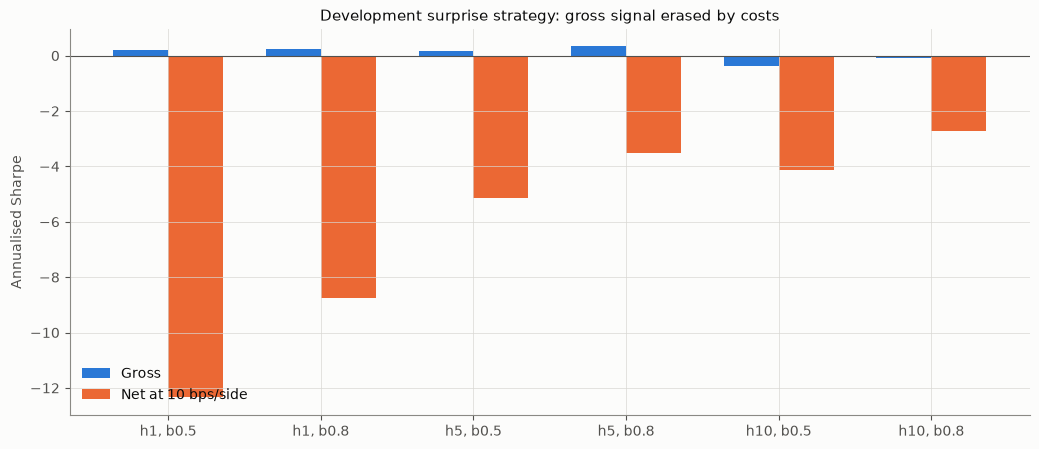

In [8]:
plot_sweep = sweep.loc[sweep["signal"].eq("surprise_firm")].copy()
plot_sweep["label"] = plot_sweep.apply(
    lambda row: f"h{int(row['horizon'])}, b{row['breadth']:.1f}", axis=1
)
plot_sweep = plot_sweep.sort_values(["horizon", "breadth"])
x = np.arange(len(plot_sweep))
width = 0.36

fig, ax = plt.subplots(figsize=(10.5, 4.6))
ax.bar(x - width / 2, plot_sweep["sharpe_gross"], width, label="Gross", color=CATEGORICAL[0])
ax.bar(x + width / 2, plot_sweep["sharpe_net"], width, label="Net at 10 bps/side", color=CATEGORICAL[1])
ax.axhline(0, color=INK["reference"], linewidth=0.8)
ax.set_xticks(x, plot_sweep["label"])
ax.set_ylabel("Annualised Sharpe")
ax.set_title("Development surprise strategy: gross signal erased by costs")
ax.legend(loc="lower left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "development_gross_net_sharpe.png", dpi=170, bbox_inches="tight")
plt.show()

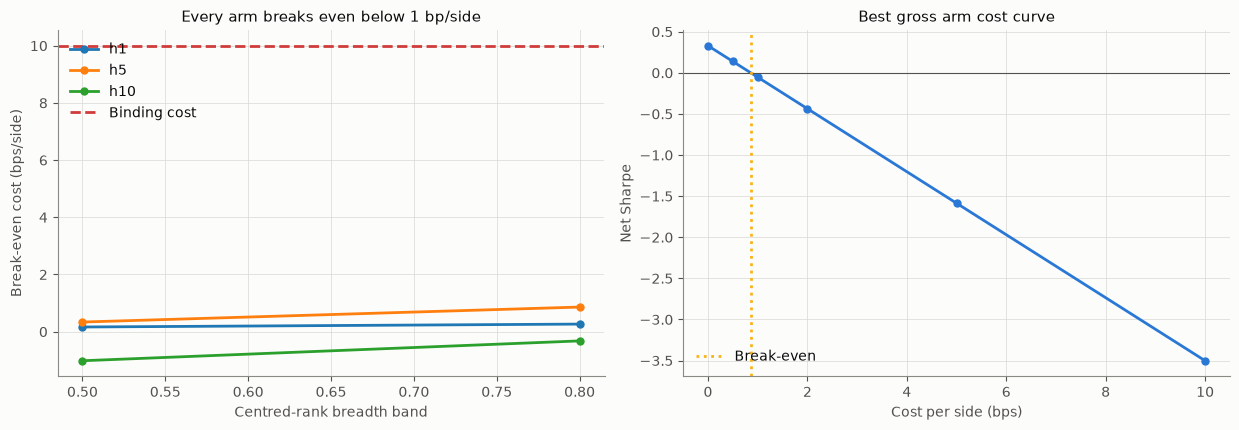

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
for horizon, group in plot_sweep.groupby("horizon"):
    axes[0].plot(
        group["breadth"],
        group["breakeven_bps_per_side"],
        marker="o",
        label=f"h{horizon}",
    )
axes[0].axhline(COST_BPS, color=STATUS["critical"], linestyle="--", label="Binding cost")
axes[0].set_xlabel("Centred-rank breadth band")
axes[0].set_ylabel("Break-even cost (bps/side)")
axes[0].set_title("Every arm breaks even below 1 bp/side")
axes[0].legend(loc="upper left")

axes[1].plot(
    cost_curve["cost_bps_per_side"],
    cost_curve["sharpe_net"],
    marker="o",
    color=CATEGORICAL[0],
)
axes[1].axhline(0, color=INK["reference"], linewidth=0.8)
axes[1].axvline(
    float(best_gross_row["breakeven_bps_per_side"]),
    color=STATUS["warning"],
    linestyle=":",
    label="Break-even",
)
axes[1].set_xlabel("Cost per side (bps)")
axes[1].set_ylabel("Net Sharpe")
axes[1].set_title("Best gross arm cost curve")
axes[1].legend(loc="lower left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "breakeven_and_cost_curve.png", dpi=170, bbox_inches="tight")
plt.show()

## Persist aggregate evidence and decide

In [10]:
input_audit.to_csv(OUTPUT_DIR / "input_audit.csv", index=False)
rank_audit.to_csv(OUTPUT_DIR / "rank_invariance.csv", index=False)
sweep.to_csv(OUTPUT_DIR / "development_sweep.csv", index=False)
gate_table.to_csv(OUTPUT_DIR / "deployment_gate.csv", index=False)
cost_curve.to_csv(OUTPUT_DIR / "best_gross_cost_curve.csv", index=False)
best_path.to_parquet(OUTPUT_DIR / "best_gross_development_daily.parquet", index=False)

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None

best_at_primary_cost = cost_curve.loc[
    cost_curve["cost_bps_per_side"].eq(COST_BPS)
].iloc[0]
manifest = {
    "notebook": "22_fnspid_surprise_strategy_translation",
    "built_for": "development-only economic translation of Notebook 4 sentiment surprise",
    "analysis_status": "exploratory_development_only_frozen_before_notebook22_execution_2026-08-05",
    "git_commit_at_execution": git_commit,
    "spine": "FNSPID_only",
    "evaluation_opened_by_notebook22": False,
    "family": {
        "signals": list(SIGNALS),
        "horizons": list(HORIZONS),
        "breadths": list(BREADTHS),
        "cost_bps_per_side": COST_BPS,
        "min_names": MIN_NAMES,
        "n_arms": len(sweep),
    },
    "rank_invariance": json.loads(rank_audit.to_json(orient="records"))[0],
    "maximum_paired_signal_result_difference": max_signal_result_difference,
    "deployment_gate": deployment,
    "best_gross_development_arm": {
        "signal": best_config.signal,
        "horizon": best_config.horizon,
        "breadth": best_config.breadth,
        "gross_sharpe": float(best_gross_row["sharpe_gross"]),
        "break_even_bps_per_side": float(best_gross_row["breakeven_bps_per_side"]),
        "net_sharpe_at_10_bps": float(best_at_primary_cost["sharpe_net"]),
    },
    "verdict": (
        "Cash. Surprise improves prediction loss at tiny scale but the complete development strategy "
        "family fails the 10-bps cost-and-uncertainty gate; evaluation is not opened."
    ),
    "limitations": [
        "Notebook 4 evaluation evidence motivated this retrospective translation",
        "the portfolio screen itself uses development only",
        "FNSPID date-only timing retains the conservative next-session assumption",
        "market-adjusted returns do not remove sector or style exposures",
        "the price panel uses split-adjusted opens without dividends",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2, allow_nan=True) + "\n")

display(
    Markdown(
        f"""### Decision

**Cash; Notebook 22 does not open evaluation.**

- All **{len(sweep)} / {len(sweep)}** development arms fail the existing
  cost-and-uncertainty gate.
- The best gross arm is `{best_config.signal}`, h={best_config.horizon},
  breadth={best_config.breadth:.1f}: gross Sharpe
  **{best_gross_row['sharpe_gross']:.3f}**, break-even only
  **{best_gross_row['breakeven_bps_per_side']:.3f} bps/side**, and net Sharpe
  **{best_at_primary_cost['sharpe_net']:.3f}** at the binding 10 bps.
- Firm-only and fully demeaned surprise have exactly the same within-day ranks
  and therefore identical strategy paths. The cross-sectional demeaning layer
  improves the regression interpretation, not the tradable ordering.

This closes the missing bridge between Notebook 4's small predictive-loss
result and economic use: the effect is measurable but far below implementable
cost scale.
"""
    )
)

### Decision

**Cash; Notebook 22 does not open evaluation.**

- All **12 / 12** development arms fail the existing
  cost-and-uncertainty gate.
- The best gross arm is `surprise_firm`, h=5,
  breadth=0.8: gross Sharpe
  **0.330**, break-even only
  **0.861 bps/side**, and net Sharpe
  **-3.502** at the binding 10 bps.
- Firm-only and fully demeaned surprise have exactly the same within-day ranks
  and therefore identical strategy paths. The cross-sectional demeaning layer
  improves the regression interpretation, not the tradable ordering.

This closes the missing bridge between Notebook 4's small predictive-loss
result and economic use: the effect is measurable but far below implementable
cost scale.


## Next-step rule

Do not tune surprise holding periods, breadth, or thresholds on evaluation.
Revisit only if genuinely lower executable costs, point-in-time sector data,
or a new unseen return sample changes the feasibility premise.